# UNI - ACTIVIDAD II - LLM

In [28]:
from datasets import load_dataset
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

from nltk.corpus import stopwords
from nltk.util import ngrams

from wordcloud import WordCloud

np.random.seed(42)

## DataSet

Descarga PolyAI/banking77

In [9]:
targetFolder = "../datasets/banking77"

# Intenta cargar el dataset
dataset = load_dataset("PolyAI/banking77", trust_remote_code=True)

# Ver la estructura
print(dataset)

trainDataset = dataset["train"]
testDataset = dataset["test"]

trainPath = os.path.join(targetFolder, "train.csv")
testPath = os.path.join(targetFolder, "test.csv")

trainDataset.to_csv(trainPath, index=False)
testDataset.to_csv(testPath, index=False)

print(f"✅ Train guardado en: {trainPath}")
print(f"✅ Test guardado en: {testPath}")


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})


Creating CSV from Arrow format:   0%|          | 0/11 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

✅ Train guardado en: ../datasets/banking77/train.csv
✅ Test guardado en: ../datasets/banking77/test.csv


## Carga de archivos locales (descargados)

Una vez se descargaron los archivos del repositorio PolyAI/banking77, se cargan localmente para agilizar el trabajo.

In [20]:
from datasets import load_dataset

# Rutas a tus archivos locales
datasetFolder = "../datasets/banking77"
trainCsv = f"{datasetFolder}/train.csv"
testCsv = f"{datasetFolder}/test.csv"

# Carga los CSV locales como un dataset
dataset = load_dataset(
    "csv",
    data_files={
        "train": trainCsv,
        "test": testCsv
    }
)

# Accede a los splits
train_dataset = dataset["train"]
test_dataset = dataset["test"]

trainDf = pd.DataFrame(train_dataset)
testDf = pd.DataFrame(test_dataset)

print(dataset)

print(f"Train: {len(train_dataset)} filas")  # 10003
print(f"Test: {len(test_dataset)} filas")    # 3080
print(f"Columnas: {train_dataset.column_names}")  # ['text', 'label']

trainDf.head()

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})
Train: 10003 filas
Test: 3080 filas
Columnas: ['text', 'label']


,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11


## Análisis Exploratorio de los Datos (EDA)

Convertir datasets a pandas para facilitar el análisis

In [22]:
df_train = train_dataset.to_pandas()
df_test = test_dataset.to_pandas()

print(f"Train: {df_train.shape}, Test: {df_test.shape}")
print(df_train.head())


Train: (10003, 2), Test: (3080, 2)
                                                text  label
0                     I am still waiting on my card?     11
1  What can I do if my card still hasn't arrived ...     11
2  I have been waiting over a week. Is the card s...     11
3  Can I track my card while it is in the process...     11
4  How do I know if I will get my card, or if it ...     11


### Longitud y número de palabras por comentario

In [23]:
# ---------------------------------------------------------
# a. Calcular longitud y número de palabras por comentario
# ---------------------------------------------------------
df_train["char_length"] = df_train["text"].apply(len)
df_train["word_count"] = df_train["text"].apply(lambda x: len(x.split()))

# Lo mismo para test (útil para comparar)
df_test["char_length"] = df_test["text"].apply(len)
df_test["word_count"] = df_test["text"].apply(lambda x: len(x.split()))

### Estadísticas descriptivas


=== Estadísticas descriptivas (Train) ===
        char_length    word_count
count  10003.000000  10003.000000
mean      59.473758     11.949415
std       40.867901      7.891577
min       13.000000      2.000000
25%       36.000000      7.000000
50%       47.000000     10.000000
75%       64.000000     13.000000
max      433.000000     79.000000

=== Estadísticas descriptivas (Test) ===
       char_length   word_count
count  3080.000000  3080.000000
mean     54.232468    10.952597
std      34.658008     6.688180
min      13.000000     2.000000
25%      35.000000     7.000000
50%      45.000000     9.000000
75%      60.000000    12.000000
max     368.000000    69.000000


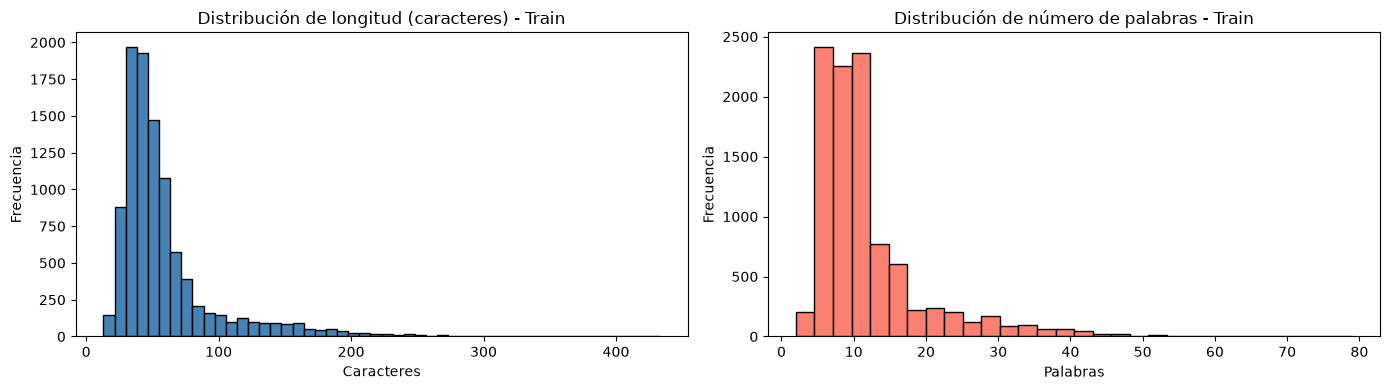

In [24]:
# ---------------------------------------------------------
# b. Estadísticas descriptivas
# ---------------------------------------------------------
print("\n=== Estadísticas descriptivas (Train) ===")
print(df_train[["char_length", "word_count"]].describe())

print("\n=== Estadísticas descriptivas (Test) ===")
print(df_test[["char_length", "word_count"]].describe())

# Visualización opcional
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_train["char_length"], bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Distribución de longitud (caracteres) - Train")
axes[0].set_xlabel("Caracteres")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(df_train["word_count"], bins=30, color="salmon", edgecolor="black")
axes[1].set_title("Distribución de número de palabras - Train")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()


### Limpieza básica del texto

In [25]:
# ---------------------------------------------------------
# c. Limpieza básica del texto
# ---------------------------------------------------------
stop_words = set(stopwords.words("english"))

def limpiar_texto(texto):
    # 1. Convertir a minúsculas
    texto = texto.lower()
    # 2. Eliminar caracteres especiales (dejar solo letras y espacios)
    texto = re.sub(r"[^a-z\s]", "", texto)
    # 3. Eliminar espacios extra
    texto = re.sub(r"\s+", " ", texto).strip()
    # 4. Eliminar stopwords
    palabras = [w for w in texto.split() if w not in stop_words]
    return " ".join(palabras)

df_train["text_clean"] = df_train["text"].apply(limpiar_texto)
df_test["text_clean"] = df_test["text"].apply(limpiar_texto)

print("\n=== Ejemplo de limpieza ===")
print("Original :", df_train["text"].iloc[0])
print("Limpio   :", df_train["text_clean"].iloc[0])


=== Ejemplo de limpieza ===
Original : I am still waiting on my card?
Limpio   : still waiting card


### 15 palabras más frecuentes


=== Top 15 palabras más frecuentes (Train) ===
card            2672
account         1348
money           1130
transfer        1081
get             808
payment         746
need            698
cash            690
top             616
exchange        549
charged         528
please          514
atm             474
app             469
fee             456


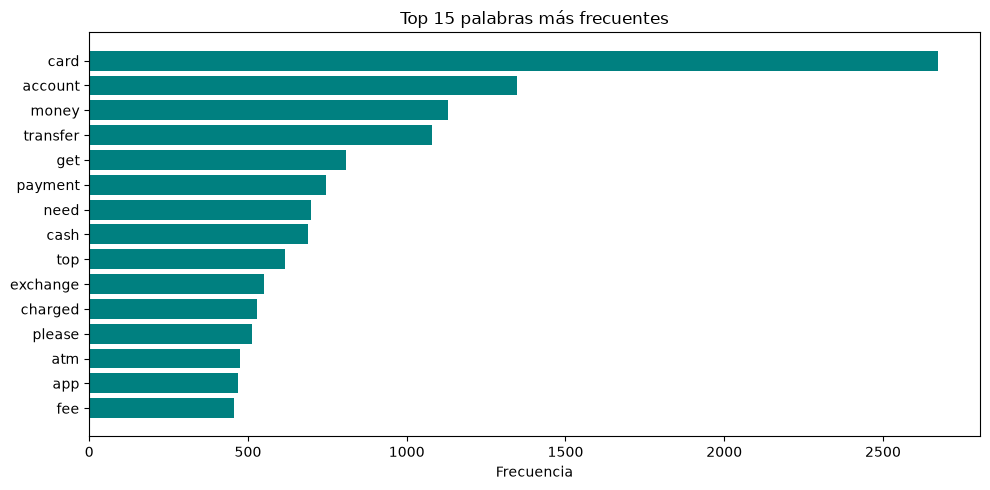

In [26]:
# ---------------------------------------------------------
# d. 15 palabras más frecuentes (sobre texto limpio)
# ---------------------------------------------------------
todas_palabras = " ".join(df_train["text_clean"]).split()
frecuencias = Counter(todas_palabras)
top_15 = frecuencias.most_common(15)

print("\n=== Top 15 palabras más frecuentes (Train) ===")
for palabra, freq in top_15:
    print(f"{palabra:15s} {freq}")

# Gráfico
palabras, freqs = zip(*top_15)
plt.figure(figsize=(10, 5))
plt.barh(palabras[::-1], freqs[::-1], color="teal")
plt.title("Top 15 palabras más frecuentes")
plt.xlabel("Frecuencia")
plt.tight_layout()
plt.show()

### 10 bigramas y 10 trigramas más frecuentes

In [29]:
# ---------------------------------------------------------
# e. 10 bigramas y 10 trigramas más frecuentes
# ---------------------------------------------------------
def top_ngramas(textos, n, top=10):
    todos = []
    for texto in textos:
        tokens = texto.split()
        todos.extend(list(ngrams(tokens, n)))
    return Counter(todos).most_common(top)

top_bigramas = top_ngramas(df_train["text_clean"], 2, 10)
top_trigramas = top_ngramas(df_train["text_clean"], 3, 10)

print("\n=== Top 10 bigramas ===")
for bg, freq in top_bigramas:
    print(f"{' '.join(bg):30s} {freq}")

print("\n=== Top 10 trigramas ===")
for tg, freq in top_trigramas:
    print(f"{' '.join(tg):40s} {freq}")


=== Top 10 bigramas ===
exchange rate                  293
new card                       225
card payment                   201
virtual card                   180
would like                     166
cash withdrawal                165
money account                  128
please help                    121
long take                      121
still pending                  119

=== Top 10 trigramas ===
disposable virtual card                  63
exchange rate wrong                      41
get money back                           36
charged extra fee                        33
direct debit payment                     33
get new card                             31
transfer money account                   29
get virtual card                         28
exchange rate applied                    27
would like know                          26


### Nube de palabras

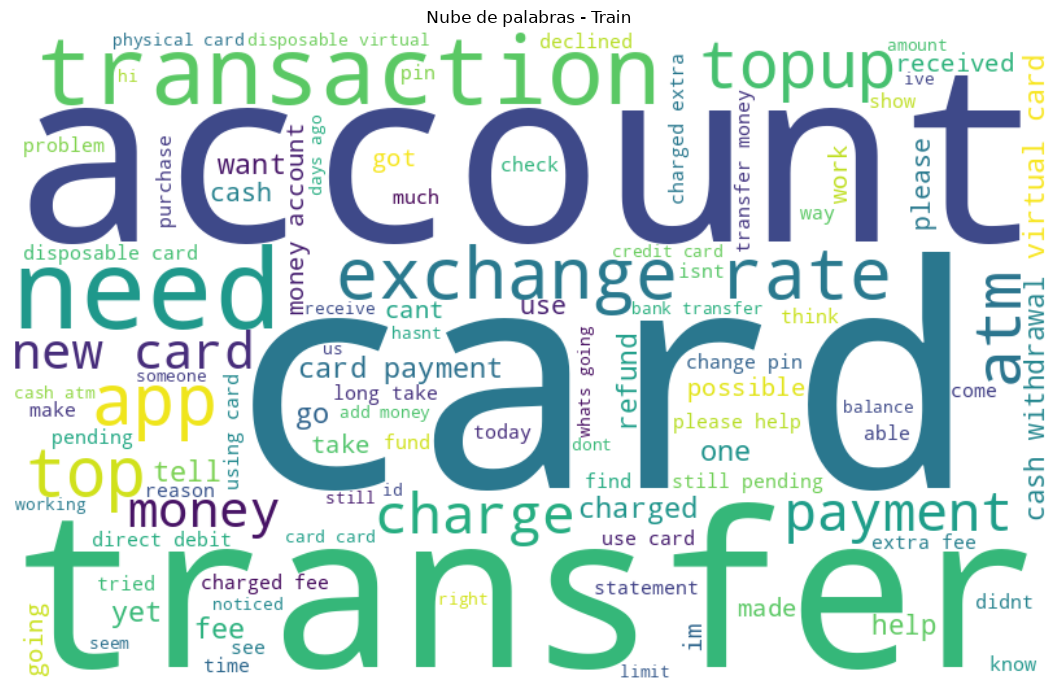

In [31]:
# ---------------------------------------------------------
# f. Nube de palabras
# ---------------------------------------------------------
texto_completo = " ".join(df_train["text_clean"])

wordcloud = WordCloud(
    width=800,
    height=500,
    background_color="white",
    colormap="viridis",
    max_words=100
).generate(texto_completo)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - Train")
plt.tight_layout()
plt.show()

### Verificar si el conjunto de datos se encuentra balanceado


=== Balance de clases (Train) ===
Número de clases: 77
Media de ejemplos por clase: 129.91
Desviación estándar: 32.94
Mínimo: 35, Máximo: 187


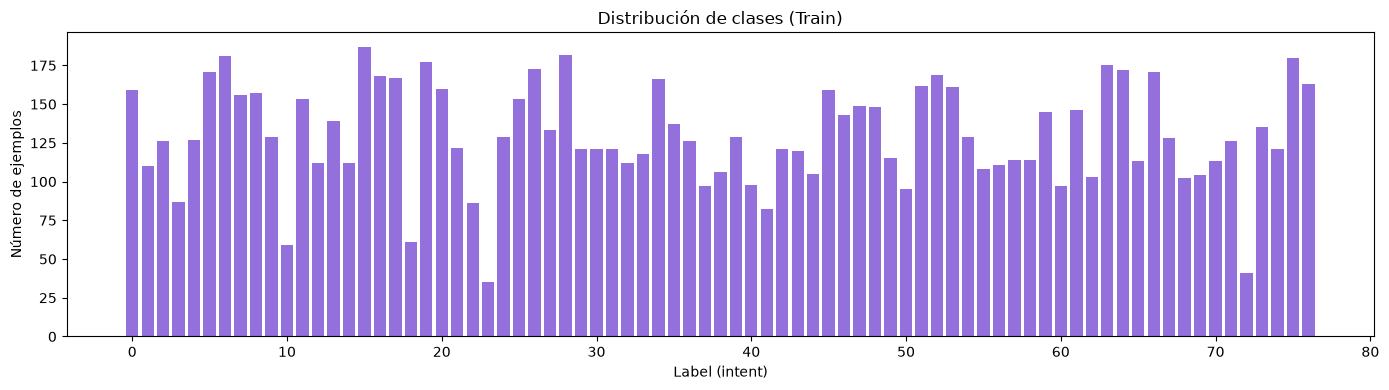

Coeficiente de variación: 0.254
→ El dataset está moderadamente balanceado.


In [32]:
conteo_labels = df_train["label"].value_counts().sort_index()

print("\n=== Balance de clases (Train) ===")
print(f"Número de clases: {df_train['label'].nunique()}")
print(f"Media de ejemplos por clase: {conteo_labels.mean():.2f}")
print(f"Desviación estándar: {conteo_labels.std():.2f}")
print(f"Mínimo: {conteo_labels.min()}, Máximo: {conteo_labels.max()}")

# Visualización
plt.figure(figsize=(14, 4))
plt.bar(conteo_labels.index, conteo_labels.values, color="mediumpurple")
plt.title("Distribución de clases (Train)")
plt.xlabel("Label (intent)")
plt.ylabel("Número de ejemplos")
plt.tight_layout()
plt.show()

# Coeficiente de variación (más bajo = más balanceado)
cv = conteo_labels.std() / conteo_labels.mean()
print(f"Coeficiente de variación: {cv:.3f}")
if cv < 0.1:
    print("→ El dataset está prácticamente balanceado.")
elif cv < 0.3:
    print("→ El dataset está moderadamente balanceado.")
else:
    print("→ El dataset está desbalanceado.")

### Conclusiones EDA

* Longitud de los comentarios: Los comentarios tienen una longitud media de ~59 caracteres y ~11 palabras en el conjunto de entrenamiento, con una distribución sesgada hacia la derecha (la mayoría son cortos, pero hay algunos muy largos). El conjunto de test tiene una distribución similar, ligeramente más corta (~54 caracteres).

* Limpieza de texto: Tras convertir a minúsculas, eliminar caracteres especiales y stopwords, el vocabulario se reduce significativamente, lo que facilita el análisis de frecuencias y reduce el ruido para modelos posteriores.

* Palabras más frecuentes: Las palabras más comunes están relacionadas con el dominio bancario (ej. card, transfer, payment, account), lo que confirma que el dataset está bien enfocado en un único dominio.

* Bigramas y trigramas: Los n-gramas más frecuentes revelan patrones típicos de consultas de clientes (ej. "card not working", "pending transfer"), útiles para identificar intenciones.

* Balance del dataset: El dataset tiene 77 clases con una distribución casi uniforme (coeficiente de variación bajo), lo que significa que está balanceado y no requiere técnicas de remuestreo para el entrenamiento.

* Implicaciones: El dataset es adecuado para tareas de clasificación de intenciones con modelos supervisados. Su tamaño moderado (~13k ejemplos) y su naturaleza balanceada lo hacen ideal para benchmarking de modelos de NLP.


## Clasificación con Transformer DistilRoBERTa

Importando las librerias necesarias:

In [34]:
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
)
import matplotlib.pyplot as plt
import seaborn as sns